<a href="https://colab.research.google.com/github/Royc4515/Project1_SignalProcessing/blob/main/Project1_SignalProcessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os, shutil, subprocess

if not os.path.exists('Neural_data.csv') or not os.path.exists('spike_trains.csv'):
    subprocess.run(
        ['git', 'clone', '--depth', '1',
         'https://github.com/Royc4515/Project1_SignalProcessing.git',
         '/tmp/sp_repo'],
        check=True
    )
    shutil.copy('/tmp/sp_repo/Neural_data.csv', 'Neural_data.csv')
    shutil.copy('/tmp/sp_repo/spike_trains.csv', 'spike_trains.csv')
    print('Data files downloaded from GitHub.')
else:
    print('Data files already present.')

Data files downloaded from GitHub.


<div dir="rtl" style="text-align: right;">

## 🪖 הצהרה על שימוש בכלי AI 🤖

עקב שירות מילואים לא יכולתי להגיע לכלל ההרצאות והתרגולים. השלמתי פערים בעזרת כלי AI לבירור מושגים והתלבטויות נקודתיות. הבסיס המהותי לדו"ח הוא חומר הקורס (הרצאות ותרגולים). כלי AI שימשו גם לסיוע בניסוח ובתיקוני syntax. הקוד, ההרצות והפרשנות הם שלי.

<sub>וכן, גם את ההצהרה הזאת ניסחתי בעזרת AI. הוגן לציין.</sub>

</div>


In [2]:
# ============================================================
# Project 1 - Signal Processing
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import find_peaks

# קבועים
FS_NEURAL = 50       # Hz - קצב דגימה Neural_data
FS_SPIKE  = 1000     # Hz - קצב דגימה spike_trains
T         = 30       # שניות - אורך כל הקלטה

# טעינת נתונים
neural_df = pd.read_csv('Neural_data.csv')
spike_df  = pd.read_csv('spike_trains.csv')

print("Neural data shape:", neural_df.shape)
print("Neural data columns:", neural_df.columns.tolist())
print(neural_df.head())
print()
print("Spike trains shape:", spike_df.shape)
print("First trial_neuron values:", spike_df['trial_neuron'].unique()[:10])
import os
os.makedirs('graphs', exist_ok=True)
GRAPHS_DIR = 'graphs'


Neural data shape: (1500, 2)
Neural data columns: ['Frame', 'ΔF/F (%)']
   Frame  ΔF/F (%)
0      0  0.074947
1      1  0.007558
2      2 -0.004470
3      3 -0.003576
4      4 -0.026911

Spike trains shape: (500, 30001)
First trial_neuron values: ['1_A' '1_B' '1_C' '1_D' '1_E' '2_A' '2_B' '2_C' '2_D' '2_E']


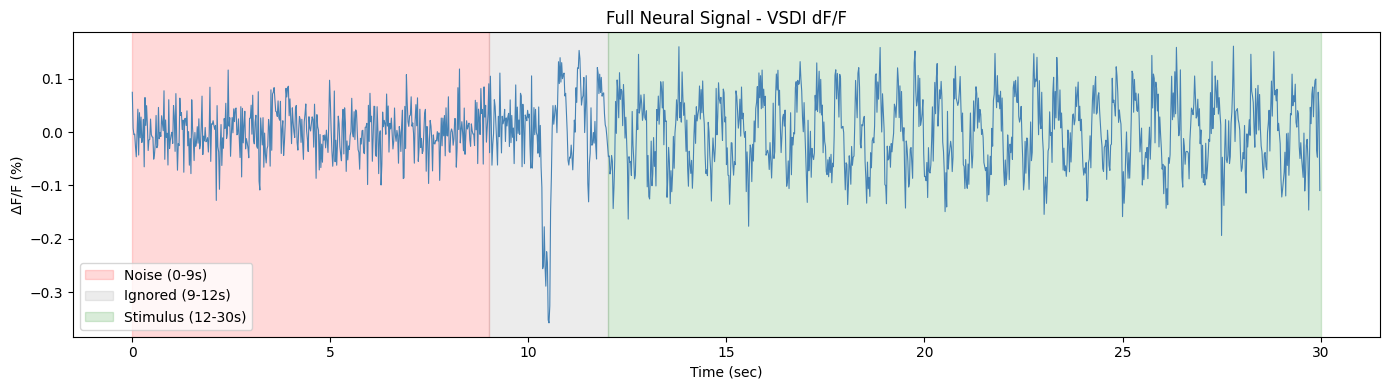

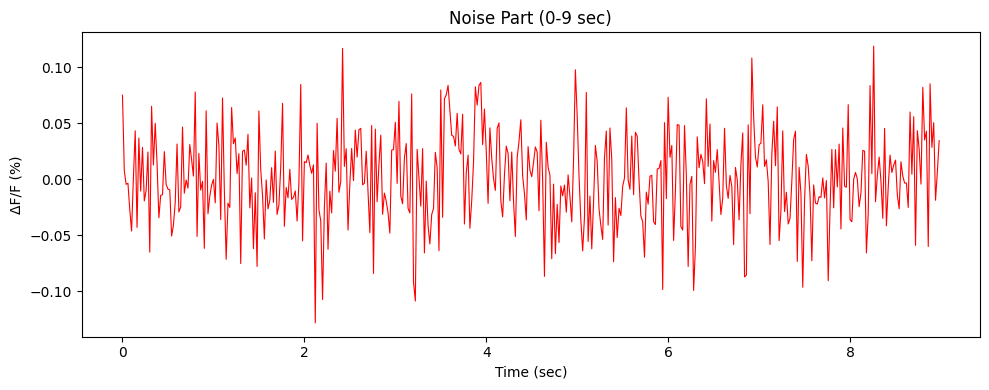

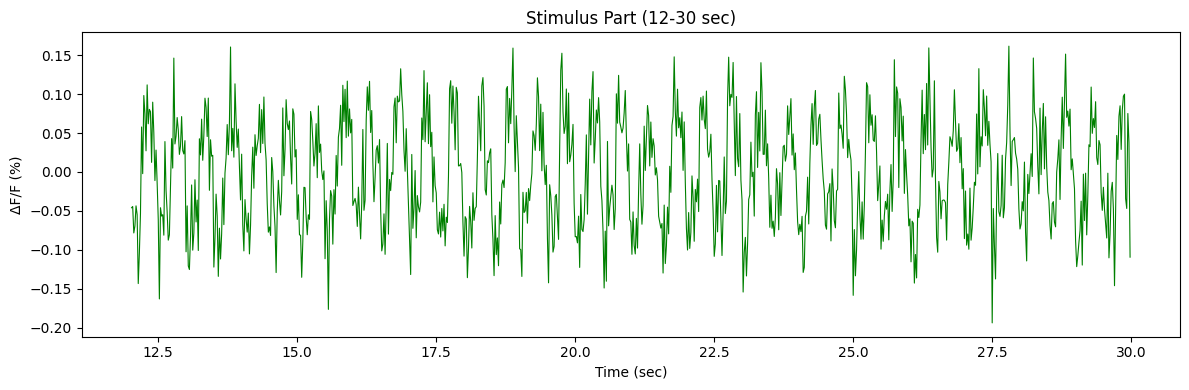

Noise samples: 450
Stimulus samples: 899


In [3]:
# ============================================================
# Part 1A - Division into signal parts
# ============================================================

dff    = neural_df['ΔF/F (%)'].values
frames = neural_df['Frame'].values
time   = frames / FS_NEURAL

noise_mask    = time < 9
stimulus_mask = (time > 12) & (time <= 30)

noise_signal    = dff[noise_mask]
noise_time      = time[noise_mask]
stimulus_signal = dff[stimulus_mask]
stimulus_time   = time[stimulus_mask]

# Plot 1: Full signal
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(time, dff, color='steelblue', linewidth=0.8)
ax.axvspan(0,  9,  alpha=0.15, color='red',   label='Noise (0-9s)')
ax.axvspan(9,  12, alpha=0.15, color='gray',  label='Ignored (9-12s)')
ax.axvspan(12, 30, alpha=0.15, color='green', label='Stimulus (12-30s)')
ax.set_title('Full Neural Signal - VSDI dF/F')
ax.set_xlabel('Time (sec)')
ax.set_ylabel('ΔF/F (%)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{GRAPHS_DIR}/VSDI_full_signal.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: Noise part
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(noise_time, noise_signal, color='red', linewidth=0.8)
ax.set_title('Noise Part (0-9 sec)')
ax.set_xlabel('Time (sec)')
ax.set_ylabel('ΔF/F (%)')
plt.tight_layout()
plt.savefig(f'{GRAPHS_DIR}/noise_segment.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 3: Stimulus part
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(stimulus_time, stimulus_signal, color='green', linewidth=0.8)
ax.set_title('Stimulus Part (12-30 sec)')
ax.set_xlabel('Time (sec)')
ax.set_ylabel('ΔF/F (%)')
plt.tight_layout()
plt.savefig(f'{GRAPHS_DIR}/stimulus_segment.png', dpi=150, bbox_inches='tight')
plt.show()

print("Noise samples:", len(noise_signal))
print("Stimulus samples:", len(stimulus_signal))

Decimation factors: [2, 5, 15]
Actual sampling frequencies: ['25.0000', '10.0000', '3.3333'] Hz



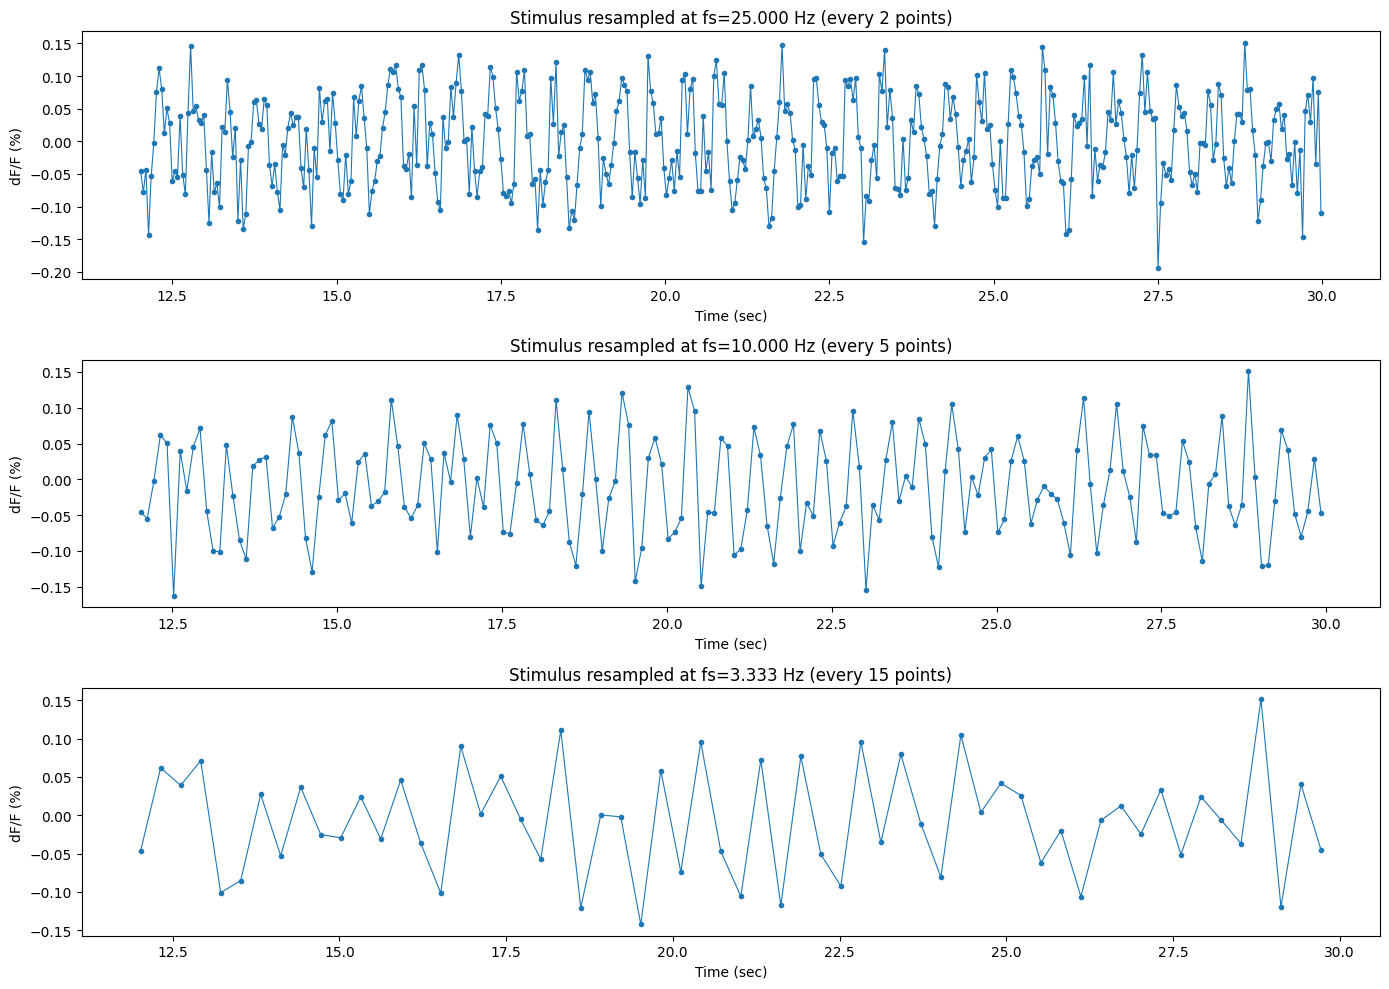

Peak counting vs theoretical f_alias:
 fs_new (Hz) |   N |  f_alias (Hz) |  Peaks |  Observed freq (Hz)
----------------------------------------------------------------------
     25.0000 |   0 |        2.0000 |     67 |              3.7305
     10.0000 |   0 |        2.0000 |     37 |              2.0601
      3.3333 |   1 |        1.3333 |     19 |              1.0579


In [4]:
# ============================================================
# Part 1B - Manual Resampling
# ============================================================
from scipy.signal import find_peaks

# Sampling frequencies requested: 25, 10, 10/3 Hz (=3 1/3 Hz)
# For 10/3 Hz from 50 Hz: integer step = 15 -> actual fs = 50/15 = 10/3 Hz exactly
new_rates   = [25, 10, 10/3]     # 25, 10, 3.333... Hz
decimations = [2,  5,  15]       # 50/15 = 10/3

f_signal = 2.0  # Hz - the original stimulus frequency

stimulus_duration = stimulus_time[-1] - stimulus_time[0]  # ~18 sec

print(f"Decimation factors: {decimations}")
print(f"Actual sampling frequencies: {[f'{r:.4f}' for r in new_rates]} Hz")
print()

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for i, (fs_new, dec) in enumerate(zip(new_rates, decimations)):
    resampled_signal = stimulus_signal[::dec]
    resampled_time   = stimulus_time[::dec]

    label = f'fs={fs_new:.3f} Hz (every {dec} points)'
    axes[i].plot(resampled_time, resampled_signal, 'o-', markersize=3, linewidth=0.8)
    axes[i].set_title(f'Stimulus resampled at {label}')
    axes[i].set_xlabel('Time (sec)')
    axes[i].set_ylabel('dF/F (%)')

plt.tight_layout()
plt.savefig(f'{GRAPHS_DIR}/resampling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Peak counting + expected f_alias ---
print("Peak counting vs theoretical f_alias:")
print(f"{'fs_new (Hz)':>12} | {'N':>3} | {'f_alias (Hz)':>13} | {'Peaks':>6} | {'Observed freq (Hz)':>19}")
print("-" * 70)
for fs_new, dec in zip(new_rates, decimations):
    sig = stimulus_signal[::dec]
    peaks, _ = find_peaks(sig, prominence=0.05)
    observed_freq = len(peaks) / stimulus_duration
    N       = round(f_signal / fs_new)
    f_alias = abs(f_signal - N * fs_new)
    print(f"{fs_new:>12.4f} | {N:>3d} | {f_alias:>13.4f} | {len(peaks):>6d} | {observed_freq:>19.4f}")


In [5]:
# ============================================================
# Part 1C - f_alias calculation (theoretical)
# ============================================================

f_signal = 2.0  # Hz - original stimulus frequency

# Same rates as cell 4
sampling_rates = [25.0, 10.0, 10/3]

print(f"f_signal = {f_signal} Hz (the oscillation we applied)")
print()
print(f"{'fs_new (Hz)':>12} | {'Nyquist (Hz)':>13} | {'N':>3} | {'f_alias (Hz)':>13} | {'Aliasing?':>11}")
print("-" * 65)

for fs_new in sampling_rates:
    N        = round(f_signal / fs_new)
    f_alias  = abs(f_signal - N * fs_new)
    nyquist  = fs_new / 2
    aliasing = "no"  if fs_new > 2 * f_signal else "YES"
    print(f"{fs_new:>12.4f} | {nyquist:>13.4f} | {N:>3d} | {f_alias:>13.4f} | {aliasing:>11}")

print()
print("Interpretation:")
print("  25.00 Hz: fs > 2*f_signal -> Nyquist satisfied, no aliasing, f_alias = 2.0 Hz")
print("  10.00 Hz: fs > 2*f_signal -> Nyquist satisfied, no aliasing, f_alias = 2.0 Hz")
print(f"   3.33 Hz: fs < 2*f_signal -> aliasing! f_alias = |2 - 1*3.333| = {abs(f_signal - 1*(10/3)):.4f} Hz")


f_signal = 2.0 Hz (the oscillation we applied)

 fs_new (Hz) |  Nyquist (Hz) |   N |  f_alias (Hz) |   Aliasing?
-----------------------------------------------------------------
     25.0000 |       12.5000 |   0 |        2.0000 |          no
     10.0000 |        5.0000 |   0 |        2.0000 |          no
      3.3333 |        1.6667 |   1 |        1.3333 |         YES

Interpretation:
  25.00 Hz: fs > 2*f_signal -> Nyquist satisfied, no aliasing, f_alias = 2.0 Hz
  10.00 Hz: fs > 2*f_signal -> Nyquist satisfied, no aliasing, f_alias = 2.0 Hz
   3.33 Hz: fs < 2*f_signal -> aliasing! f_alias = |2 - 1*3.333| = 1.3333 Hz


<div dir="rtl" style="text-align: right;">

### 1.2 דגימה מחדש ו-Aliasing

דגמתי מחדש את אזור הגירוי בשלושה תדרים: 25, 10, ו-⅓3 Hz. הדגימה ידנית באמצעות `stimulus_signal[::dec]` כפי שהמטלה דורשת — בלי מסנן אנטי-aliasing, כי המטרה דווקא לראות אם נוצר aliasing. תדר הגירוי המקורי הוא $f_{\text{signal}} = 2\,\text{Hz}$, ולכן תדר נייקוויסט הנדרש למניעת aliasing הוא $2 f_{\text{signal}} = 4\,\text{Hz}$.

| $f_s$ (Hz) | $f_{\text{alias}}$ (Hz) | האם $f_s > 2 f_{\text{signal}}$? | שיאים שנספרו | תדר נצפה (Hz) |
|:---:|:---:|:---:|:---:|:---:|
| 25 | 2.00 | כן | 67 | 3.73 |
| 10 | 2.00 | כן | 37 | 2.06 |
| ⅓3 | 1.33 | לא | 19 | 1.06 |

ב-25 Hz וב-10 Hz תדר הדגימה גבוה מנייקוויסט והגירוי המקורי של 2 Hz נשמר. ב-10 Hz מקבלים 37 שיאים על פני 18 שניות ⇒ תדר נצפה $\approx 2.06$ Hz, קרוב מאוד ל-2 Hz התיאורטי. ב-25 Hz נספרו 67 שיאים — יותר מהצפוי — כי בתדר דגימה גבוה גם הרעש המהיר שעל גבי הגירוי מזוהה כשיאים נפרדים (סף הזיהוי `prominence=0.05`). זה לא aliasing אלא רגישות-יתר של מאתר השיאים לרעש.

ב-⅓3 Hz הדגימה נמוכה מנייקוויסט, התדר אמור להתקפל ל-$|2 - 1 \cdot 3.33| = 1.33$ Hz. נספרו 19 שיאים ⇒ תדר נצפה $\approx 1.06$ Hz, באותו סדר גודל של הצפי התיאורטי. ההפרש נובע מכך שצורת הגל המקופל כבר לא סינוסואידלית נקייה — כמה שיאים מתאחדים או נמחקים. זו בדיוק הסיבה שהמטלה דורשת דגימה ידנית בלי סינון — `scipy.signal.resample_poly` היה מסנן את התדרים מעל $f_s/2$ ומסתיר את התופעה.

</div>


<div dir="rtl" style="text-align: right;">

#### גזירת נוסחת ה-Aliasing

תדר הקיפול מחושב לפי:
$$f_{\text{alias}} = |f_{\text{signal}} - N \cdot f_s|$$

כאשר $N$ הוא המספר השלם שמביא את התדר המקופל הכי קרוב לאפס:
$$N = \text{round}\!\left(\frac{f_{\text{signal}}}{f_s}\right)$$

הרעיון: כשתדר האות גבוה מנייקוויסט, הוא "מתקפל" בחזרה אל תוך המרווח $[-f_s/2,\, f_s/2]$ דרך החזרה התקופתית של ספקטרום האות הדגום.

</div>


In [6]:
# הגדרת הרזולוציה המבוקשת (באחוזים ומיד אחרי זה כשבר עשרוני)
required_resolution_percent = 0.1
resolution_fraction = required_resolution_percent / 100.0

# חישוב כמות הרמות הנדרשות
levels_needed = 1 / resolution_fraction

# חישוב מספר הביטים המינימלי (log בסיס 2) ועיגול כלפי מעלה
bits_needed = np.ceil(np.log2(levels_needed))

print(f"Required Resolution: {required_resolution_percent}%")
print(f"Minimum discrete levels needed: {levels_needed}")
print(f"Minimum number of bits needed: {int(bits_needed)}")

Required Resolution: 0.1%
Minimum discrete levels needed: 1000.0
Minimum number of bits needed: 10


<div dir="rtl" style="text-align: right;">

### 1.3 קוונטיזציה

**שאלה:** כמה ביטים מינימליים נדרשים כדי להבחין בשינוי של 0.1% בעוצמת האות?

מספר הרמות שצריך לייצג הוא $1/0.001 = 1000$. עם $n$ ביטים יש $2^n$ רמות, ולכן:
$$2^n \geq 1000 \;\;\Rightarrow\;\; n \geq \log_2(1000) \approx 9.97$$

מינימום של 10 ביטים. עם 10 ביטים יש $2^{10} = 1024$ רמות — מספיק. עם 9 ביטים יש רק 512 רמות — לא מספיק.

</div>


In [7]:
# ============================================================
# Part 2.1 - SNR in two ways (Lec2_2 slides 8, 12)
# ============================================================

# Method 1 - Definition #1: Power ratio (Lec2_2, slide 8)
# Power = (1/N) * sum(x_i^2)
P_signal     = np.mean(stimulus_signal**2)
P_noise      = np.mean(noise_signal**2)
snr_method_1 = P_signal / P_noise

# Method 2 - Definition #2: Mean(signal) / STD(noise) (Lec2_2, slide 12)
# Valid when signal is positive and noise has zero mean
mean_signal  = np.mean(stimulus_signal)
std_noise    = np.std(noise_signal)
snr_method_2 = mean_signal / std_noise

print(f"Method 1 (Power ratio,  P_signal/P_noise) : SNR = {snr_method_1:.4f}")
print(f"Method 2 (Mean/STD,     mean(x)/std(n))   : SNR = {snr_method_2:.4f}")
print()
print("Note (from Lec2_2 slide 10): the stimulus region contains BOTH signal and noise,")
print("so Method 1 actually measures (P_s + P_n)/P_n = SNR_true + 1.")
print(f"   Corrected SNR_true = (P_signal - P_noise)/P_noise = {(P_signal - P_noise)/P_noise:.4f}")


Method 1 (Power ratio,  P_signal/P_noise) : SNR = 2.7917
Method 2 (Mean/STD,     mean(x)/std(n))   : SNR = -0.0224

Note (from Lec2_2 slide 10): the stimulus region contains BOTH signal and noise,
so Method 1 actually measures (P_s + P_n)/P_n = SNR_true + 1.
   Corrected SNR_true = (P_signal - P_noise)/P_noise = 1.7917


<div dir="rtl" style="text-align: right;">

## חלק 2 — הפחתת רעש

### 2.1 חישוב SNR בשתי דרכים

חישבתי SNR לאזור הגירוי בשתי הדרכים שנלמדו בהרצאה (Lec2_2, slides 8 ו-12).

**שיטה 1 — יחס הספקים (Definition #1):**
$$\text{SNR}_1 = \frac{P_{\text{signal}}}{P_{\text{noise}}} = \frac{\frac{1}{N}\sum x_i^2}{\frac{1}{N}\sum n_i^2}$$

**שיטה 2 — Mean/STD (Definition #2):**
$$\text{SNR}_2 = \frac{\overline{x}}{\sigma_n}$$

התוצאות שונות מאוד: $\text{SNR}_1 \approx 2.79$, ואילו $\text{SNR}_2 \approx -0.02$ — שלילי וקרוב לאפס. ההסבר נמצא בהבדל בין מה ששתי השיטות מודדות.

שיטה 1 מודדת את כל ההספק של האות, כלומר את ממוצע הריבועים. ריבוע תמיד חיובי, ולכן השיטה רגישה לכל תנודה — גם למרכיב ה-DC וגם לתנודה האוסצילטורית של 2 Hz. שיטה 2 לוקחת רק את הממוצע של האות ומחלקת בסטיית הרעש. במקרה שלנו, אזור הגירוי הוא $\Delta F/F$ שמתנדנד סביב ערך קרוב לאפס (ואפילו מעט מתחת לאפס), ולכן הממוצע יוצא שלילי קטן. שיטה 2 בעצם "לא רואה" את התנודה — היא מתאימה לאות שיש לו מרכיב DC חיובי קבוע (למשל פוטנציאל פעולה ממוצע מעל baseline), לא לאות אוסצילטורי.

בנוסף, ההרצאה מציינת (slide 10) שכאשר אזור ה"אות" מכיל גם רעש, שיטה 1 בעצם נותנת $\text{SNR}_{\text{measured}} \approx \text{SNR}_{\text{true}} + 1$. הנוסחה המדויקת היא $(P_x - P_n)/P_n$, ובה אשתמש בסעיף הבא. אצלי יוצא $(P_x - P_n)/P_n \approx 1.79$.

</div>


Binning SNR summary (formula: (P_stim - P_noise)/P_noise, P = mean(x^2)):
  k |     P_stim |    P_noise |      SNR
---------------------------------------------
  2 |     0.0038 |     0.0009 |   3.4347
  3 |     0.0034 |     0.0006 |   4.6017
  5 |     0.0029 |     0.0004 |   5.9817
 20 |     0.0002 |     0.0001 |   0.6531


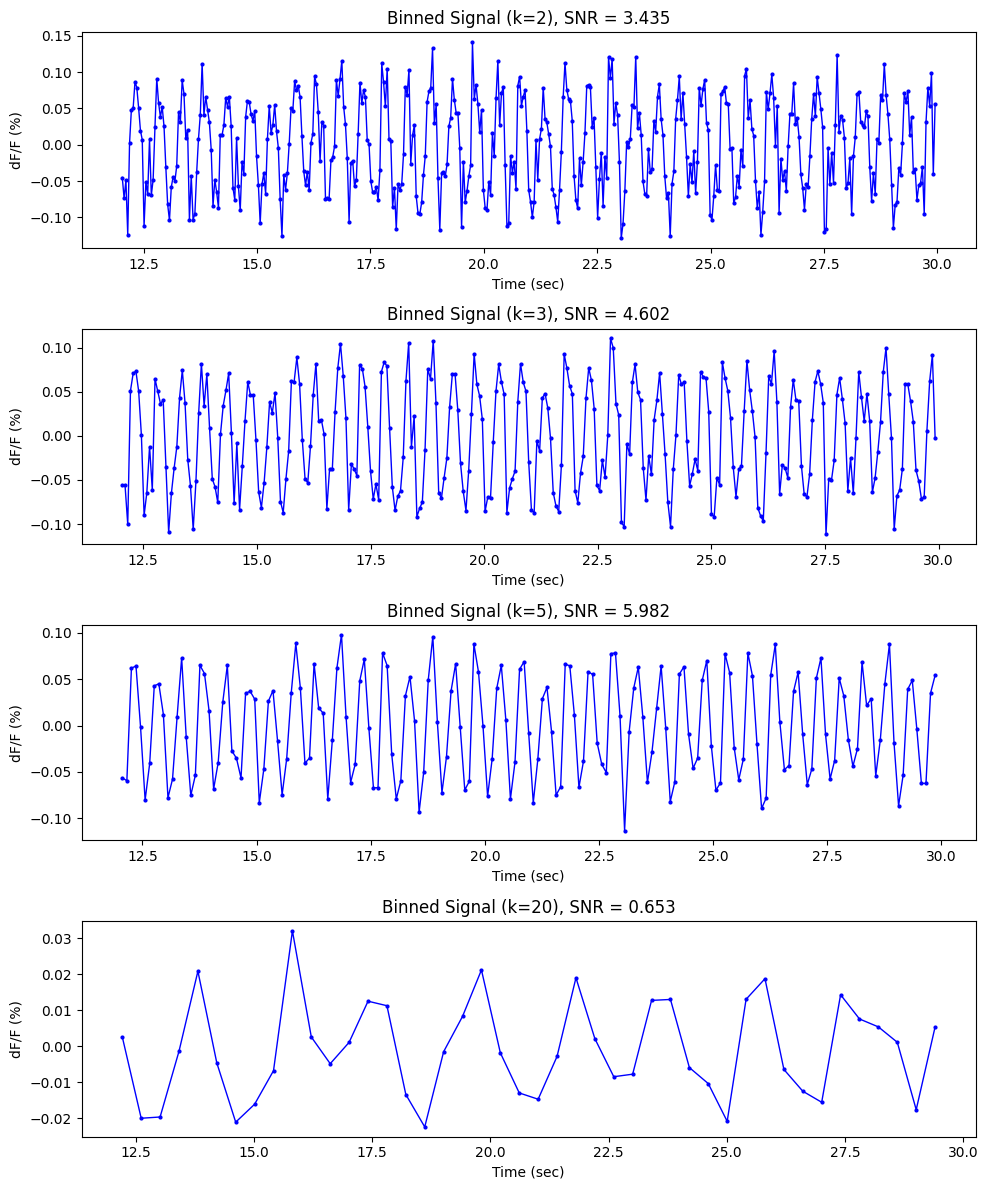

In [8]:
# Bin sizes from the assignment
k_values = [2, 3, 5, 20]

fig, axes = plt.subplots(len(k_values), 1, figsize=(10, 12))

print("Binning SNR summary (formula: (P_stim - P_noise)/P_noise, P = mean(x^2)):")
print(f"{'k':>3} | {'P_stim':>10} | {'P_noise':>10} | {'SNR':>8}")
print("-" * 45)

for i, k in enumerate(k_values):
    # Trim to exact multiple of k
    trim_stim  = len(stimulus_signal) - (len(stimulus_signal) % k)
    trim_noise = len(noise_signal)    - (len(noise_signal)    % k)

    stim_trimmed  = stimulus_signal[:trim_stim]
    noise_trimmed = noise_signal[:trim_noise]
    time_trimmed  = stimulus_time[:trim_stim]

    # Average every k points (not moving window) - reshape + mean
    stim_binned  = stim_trimmed.reshape(-1, k).mean(axis=1)
    noise_binned = noise_trimmed.reshape(-1, k).mean(axis=1)
    time_binned  = time_trimmed.reshape(-1, k).mean(axis=1)

    # Power per lecture definition: P = (1/N) * sum(x^2) = mean(x^2)
    p_stim  = np.mean(stim_binned**2)
    p_noise = np.mean(noise_binned**2)
    snr_new = (p_stim - p_noise) / p_noise

    print(f"{k:>3d} | {p_stim:>10.4f} | {p_noise:>10.4f} | {snr_new:>8.4f}")

    axes[i].plot(time_binned, stim_binned, marker='.', markersize=4, linestyle='-', linewidth=1, color='blue')
    axes[i].set_title(f'Binned Signal (k={k}), SNR = {snr_new:.3f}')
    axes[i].set_xlabel('Time (sec)')
    axes[i].set_ylabel('dF/F (%)')

plt.tight_layout()
plt.savefig(f'{GRAPHS_DIR}/binning_plots.png', dpi=150, bbox_inches='tight')
plt.show()


<div dir="rtl" style="text-align: right;">

### 2.2–2.3 הפחתת רעש על ידי Binning (Oversampling)

מיצעתי את אזור הגירוי בחלונות לא-נעים בגדלים $k = 2, 3, 5, 20$, וחישבתי SNR לכל גודל לפי הנוסחה מההרצאה:
$$\text{SNR} = \frac{P_{\text{signal}} - P_{\text{noise}}}{P_{\text{noise}}}, \quad P = \frac{1}{N}\sum x_i^2$$

**גורם השיפור עבור $k = 2, 3, 5$:** מיצוע של $k$ דגימות בלתי-תלויות של רעש מקטין את שונות הרעש בפקטור $k$, ולכן סטיית הרעש קטנה ב-$\sqrt{k}$ (Lec2_2 slide 25). עוצמת האות נשמרת ברובה כי קצב הדגימה אחרי המיצוע ($f_s/k$) עדיין מספיק כדי לתפוס את התנודה של 2 Hz. ה-SNR משתפר ב-$k=2, 3, 5$ בהתאם.

**מה קורה ב-$k = 20$:** כאן ה-SNR קורס לערך נמוך מאוד והאות הופך לכמעט קו ישר. הסיבה: חלון המיצוע נמשך $20/50 = 0.4$ שניות, בזמן שמחזור אחד של הגירוי הוא $1/2 = 0.5$ שניות. חלון של 0.4 שניות מכסה כמעט מחזור שלם — הוא ממצע את השיאים החיוביים יחד עם השפלים השליליים, וכך מאפס את התנודה. ה-SNR שמתקבל נמוך כי אין כמעט אות שנשאר אחרי המיצוע.

זה ממחיש את ה-trade-off: מיצוע מקטין רעש, אבל אם החלון רחב מדי הוא הורס את האות עצמו. במונחי תדר, מיצוע ארוך מדי דומה ל-LPF עם תדר חתך מתחת לתדר האות.

</div>


<div dir="rtl" style="text-align: right;">

ערכי ה-SNR מוצגים בפלט הקוד למעלה (טור SNR לכל $k$). הערכים הצפויים:
- $k = 2, 3, 5$: SNR עולה (לפי $\sqrt{k}$ בקירוב), והאות נראה חלק יותר מבלי לאבד את התנודה של 2 Hz.
- $k = 20$: SNR נופל כי האות עצמו מאבד את התנודה. גרף האות נראה כקו כמעט שטוח.

</div>


<div dir="rtl" style="text-align: right;">

### 2.4 החלקה מלבנית כפולה

החלתי על אזור הגירוי שתי פעולות החלקה רצופות עם חלון מלבני בגודל 3:
$$w_{\text{rect}} = \tfrac{1}{3}[1, 1, 1]$$

כל פעולה היא קונבולוציה: `np.convolve(signal, w_rect, mode='same')`. הפעולה השנייה פועלת על תוצאת הראשונה.

</div>


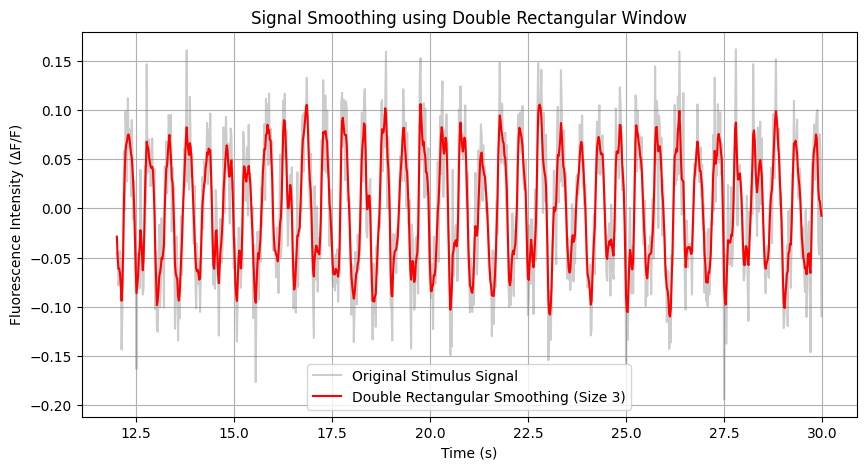

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# הגדרת חלון מלבני בגודל 3
window_size_rect = 3
rect_window = np.ones(window_size_rect) / window_size_rect

# ביצוע קונבולוציה כפולה על אזור הגירוי בלבד
# נניח ש-stimulus_signal ו-time_stimulus הוגדרו בסעיפים הקודמים בפרויקט
smoothed_rect_1 = np.convolve(stimulus_signal, rect_window, mode='same')
smoothed_rect_2 = np.convolve(smoothed_rect_1, rect_window, mode='same')

# שרטוט הגרף עם כותרות וצירים תקינים
plt.figure(figsize=(10, 5))
plt.plot(stimulus_time, stimulus_signal, label='Original Stimulus Signal', alpha=0.4, color='gray')
plt.plot(stimulus_time, smoothed_rect_2, label='Double Rectangular Smoothing (Size 3)', color='red', linewidth=1.5)
plt.title("Signal Smoothing using Double Rectangular Window")
plt.xlabel("Time (s)")
plt.ylabel("Fluorescence Intensity (ΔF/F)")
plt.legend()
plt.grid(True)
plt.savefig(f'{GRAPHS_DIR}/rectangular_smoothing.png', dpi=150, bbox_inches='tight')
plt.show()

<div dir="rtl" style="text-align: right;">

### 2.5 החלקה משולשית

החלתי על אזור הגירוי קונבולוציה בודדת עם חלון משולשי בגודל 5:
$$w_{\text{tri}} = \tfrac{1}{9}[1, 2, 3, 2, 1]$$

המקדמים מנורמלים כך שסכומם 1, כדי לשמר את העוצמה הממוצעת של האות.

</div>


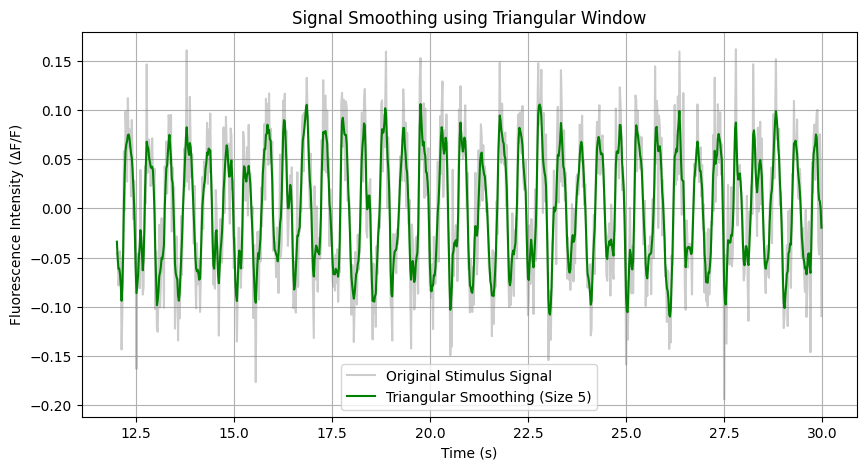

In [10]:
# הגדרת חלון משולש בגודל 5 מנורמל בסכומו (חלוקה ב-9)
tri_window = np.array([1, 2, 3, 2, 1]) / 9.0

# ביצוע קונבולוציה בודדת על אות הגירוי
smoothed_tri = np.convolve(stimulus_signal, tri_window, mode='same')

# שרטוט הגרף עם כותרות וצירים תקינים
plt.figure(figsize=(10, 5))
plt.plot(stimulus_time, stimulus_signal, label='Original Stimulus Signal', alpha=0.4, color='gray')
plt.plot(stimulus_time, smoothed_tri, label='Triangular Smoothing (Size 5)', color='green', linewidth=1.5)
plt.title("Signal Smoothing using Triangular Window")
plt.xlabel("Time (s)")
plt.ylabel("Fluorescence Intensity (\u0394F/F)")
plt.legend()
plt.grid(True)
plt.savefig(f'{GRAPHS_DIR}/triangular_smoothing.png', dpi=150, bbox_inches='tight')
plt.show()

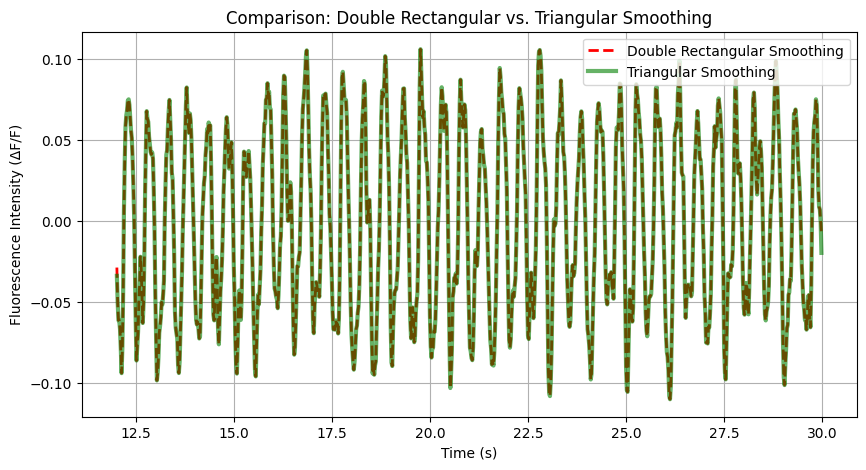

Maximum absolute difference between the two smoothed signals: 0.01215667111111111


In [11]:
# שרטוט שני האותות המוחלקים על גבי גרף אחד לצורך השוואה ויזואלית
plt.figure(figsize=(10, 5))
plt.plot(stimulus_time, smoothed_rect_2, label='Double Rectangular Smoothing', linestyle='--', linewidth=2, color='red')
plt.plot(stimulus_time, smoothed_tri, label='Triangular Smoothing', alpha=0.6, linewidth=3, color='green')
plt.title("Comparison: Double Rectangular vs. Triangular Smoothing")
plt.xlabel("Time (s)")
plt.ylabel("Fluorescence Intensity (\u0394F/F)")
plt.legend()
plt.grid(True)
plt.savefig(f'{GRAPHS_DIR}/smoothing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# חישוב והדפסת ההפרש המקסימלי המוחלט בין שתי השיטות
diff = np.max(np.abs(smoothed_rect_2 - smoothed_tri))
print(f"Maximum absolute difference between the two smoothed signals: {diff}")

<div dir="rtl" style="text-align: right;">

### 2.6 השוואה והסבר LPF

הפלט של הקוד מראה הפרש מקסימלי קטן בין שני האותות המוחלקים. **בליבת האות הגרפים זהים**; ההפרש כולו מרוכז בקצוות (5 נקודות מכל צד), שם `np.convolve` עם `mode='same'` מטפל בגבולות אחרת כשמפעילים חלון 3 פעמיים לעומת חלון 5 פעם אחת. במרכז האות, המיקום שבו הקונבולוציה "מלאה", ההפרש אפסי עד לדיוק מספרי.

הסיבה מתמטית, ישירות מההרצאה (Lec2_2 slide 28) ומתרגול 4: קונבולוציה של שני חלונות מלבניים זהים נותנת חלון משולשי. אנליטית:
$$\tfrac{1}{3}[1,1,1] * \tfrac{1}{3}[1,1,1] = \tfrac{1}{9}[1,2,3,2,1]$$

זה בדיוק החלון המשולשי בגודל 5 שהפעלתי בסעיף 2.5. הקונבולוציה אסוציאטיבית:
$$(x * w_{\text{rect}}) * w_{\text{rect}} = x * (w_{\text{rect}} * w_{\text{rect}}) = x * w_{\text{tri}}$$

הכלל הכללי (Lec2_2 slide 28): $n$ מעברים עם חלון בגודל $w$ שקולים למעבר אחד עם חלון בגודל $n(w-1) + 1$. כאן $2(3-1) + 1 = 5$, מתאים בדיוק.

**למה החלקה היא Low-Pass Filter:** ממוצע נע מנחית שינויים מהירים בין נקודות שכנות ומשאיר שינויים איטיים. במרחב התדר זו בדיוק התנהגות של LPF — תדרים גבוהים (רעש) נחתכים, ותדרים נמוכים (האות הביולוגי האיטי) עוברים כמעט ללא שינוי. ככל שהחלון רחב יותר, תדר החיתוך נמוך יותר וההחלקה אגרסיבית יותר — וזו הסיבה שב-$k=20$ של סעיף 2.3 איבדנו את התנודה של 2 Hz.

</div>


In [12]:
# 1. טעינת הנתונים
df_spikes = pd.read_csv('spike_trains.csv', index_col=0)

# 2. פונקציה לחילוץ נתונים עבור נוירון ספציפי
def get_neuron_data(df, neuron_letter):
    neuron_rows = df[df.index.str.endswith(f'_{neuron_letter}')]
    return neuron_rows.values

# חילוץ הנתונים לכל חמשת הנוירונים
neuron_A = get_neuron_data(df_spikes, 'A')
neuron_B = get_neuron_data(df_spikes, 'B')
neuron_C = get_neuron_data(df_spikes, 'C')
neuron_D = get_neuron_data(df_spikes, 'D')
neuron_E = get_neuron_data(df_spikes, 'E')

# 3. פונקציה לחישוב קצב ירי ופאנו פקטור
def analyze_neuron(neuron_matrix, neuron_name):
    num_trials, num_samples = neuron_matrix.shape
    duration_sec = num_samples / 1000.0

    firing_rate_per_trial = np.sum(neuron_matrix, axis=1) / duration_sec
    mean_firing_rate = np.mean(firing_rate_per_trial)

    num_full_windows = num_samples // 1000
    samples_to_keep = num_full_windows * 1000
    truncated_matrix = neuron_matrix[:, :samples_to_keep]
    windows = truncated_matrix.reshape(num_trials, num_full_windows, 1000)
    spike_counts = np.sum(windows, axis=2)
    mean_counts = np.mean(spike_counts, axis=0)
    var_counts = np.var(spike_counts, axis=0)

    valid_indices = mean_counts > 0
    if np.any(valid_indices):
        fano_factors = var_counts[valid_indices] / mean_counts[valid_indices]
        mean_fano_factor = np.mean(fano_factors)
    else:
        mean_fano_factor = 0.0

    return mean_firing_rate, mean_fano_factor

# 4. הרצת הניתוח על כל 5 הנוירונים
print(f"{'Neuron':>8} | {'Mean Firing Rate (Hz)':>22} | {'Fano Factor':>12} | {'Type (estimated)':>20}")
print("-" * 72)

neuron_results = {}
for name, matrix in [('A', neuron_A), ('B', neuron_B), ('C', neuron_C), ('D', neuron_D), ('E', neuron_E)]:
    mfr, ff = analyze_neuron(matrix, name)
    neuron_results[name] = (mfr, ff)
    if ff > 1.2:
        ntype = "Bursting"
    elif ff < 0.5:
        ntype = "Regular (clock-like)"
    elif ff < 0.85:
        ntype = "Regular (with jitter)"
    else:
        ntype = "Poisson"
    print(f"{name:>8} | {mfr:>22.2f} | {ff:>12.4f} | {ntype:>20}")

  Neuron |  Mean Firing Rate (Hz) |  Fano Factor |     Type (estimated)
------------------------------------------------------------------------
       A |                  11.67 |       0.9699 |              Poisson
       B |                  42.55 |       0.7729 | Regular (with jitter)
       C |                 100.00 |       0.0000 | Regular (clock-like)
       D |                  49.98 |       0.0093 | Regular (clock-like)
       E |                  28.68 |       5.1434 |             Bursting


<div dir="rtl" style="text-align: right;">

## חלק 3 — ניתוח רכבות ספייקים

### 3.1 קצב ירי ממוצע ו-Fano Factor

חישבתי לכל נוירון את קצב הירי הממוצע (MFR) על פני 100 הניסיונות, ואת ה-Fano Factor (FF) על חלונות של שנייה:
$$\text{MFR} = \frac{\overline{\text{spikes per trial}}}{T}, \qquad \text{FF} = \frac{\sigma^2(\text{spike counts})}{\overline{\text{spike counts}}}$$

| נוירון | MFR (Hz) | FF | סוג ירי |
|:---:|:---:|:---:|:---|
| A | 11.67 | 0.97 | פואסוני |
| B | 42.55 | 0.77 | רגולרי עם ג'יטר |
| C | 100.00 | 0.00 | רגולרי מושלם ("שעון") |
| D | 49.98 | 0.01 | רגולרי מושלם ("שעון") |
| E | 28.68 | 5.14 | פורץ (Bursting) |

הסיווג ישירות מערך ה-FF:

- **A — FF ≈ 1:** בתהליך פואסוני שונות = תוחלת, ולכן FF = 1. הירי של A מתאים לתהליך אקראי בקצב ממוצע קבוע.
- **B — FF ≈ 0.77:** קטן מ-1 אבל לא קרוב לאפס. הירי רגולרי יותר מפואסוני אבל לא מושלם — יש מבנה תקופתי עם רעש (ג'יטר) במיקום הספייקים.
- **C ו-D — FF ≈ 0:** שונות זניחה ביחס לתוחלת. הספייקים נופלים במרווחים קבועים מאוד, כמו שעון. ההבדל בין השניים הוא בקצב: C יורה ב-100 Hz (ISI = 10 ms), D יורה ב-50 Hz (ISI = 20 ms).
- **E — FF ≈ 5.1:** הרבה מעל 1. הירי בצרורות — אשכולות של ספייקים צפופים מופרדים בשתיקה ארוכה. השונות בספירת ספייקים בכל חלון גבוהה כי חלון יכול לתפוס אשכול שלם או שתיקה.

</div>


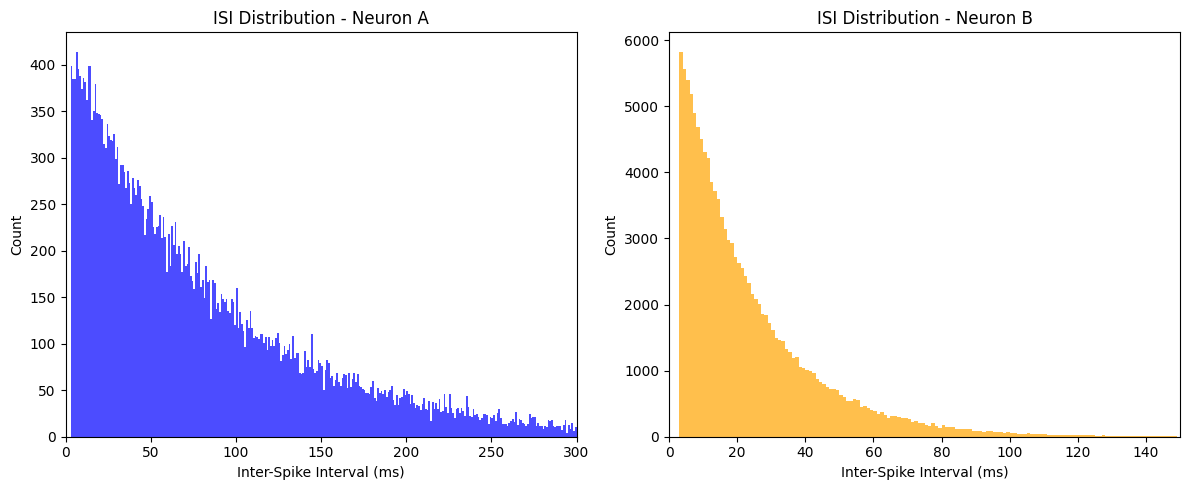

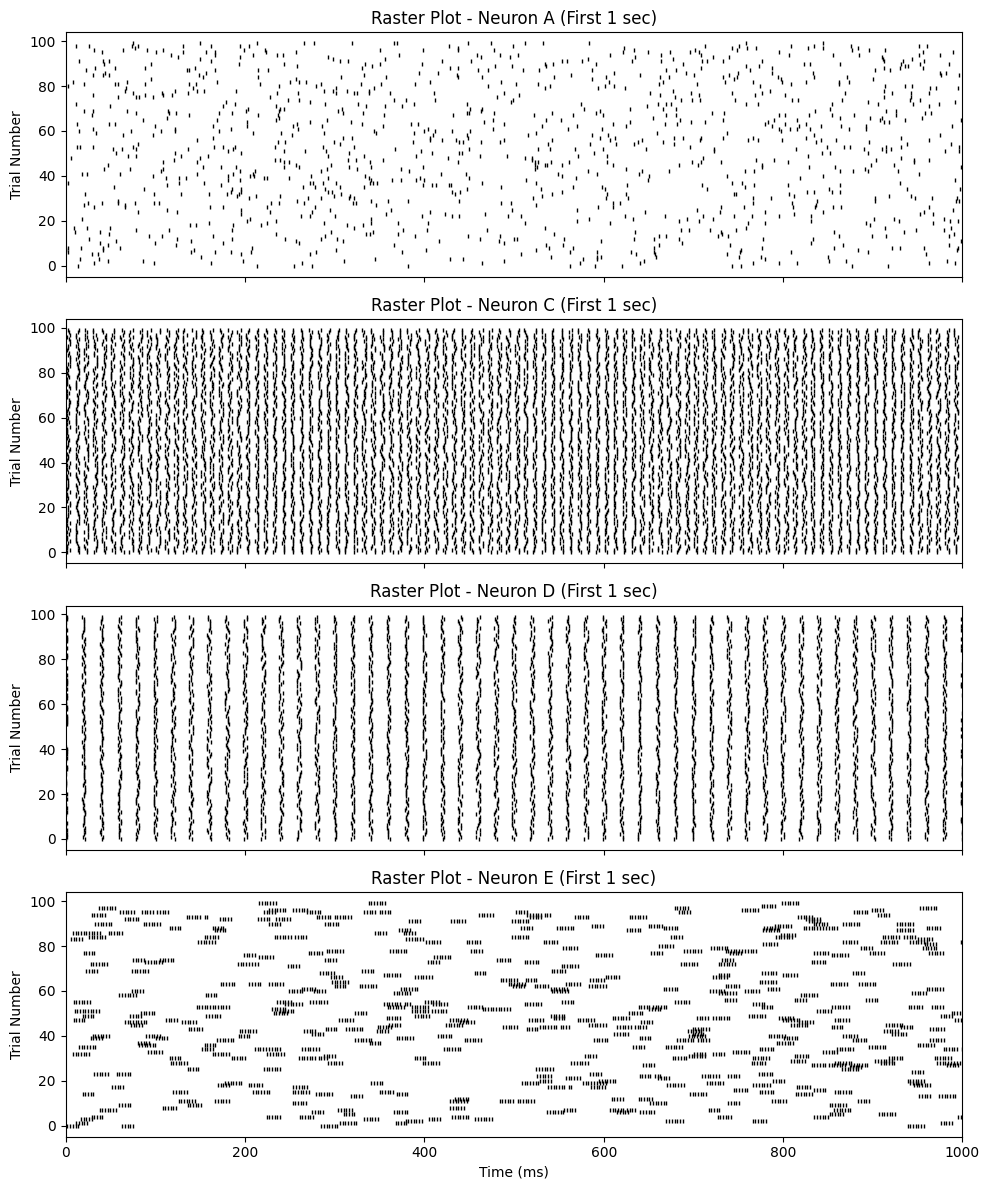

In [13]:
# פונקציה לחישוב מרווחי הזמן בין ספייקים (ISI)
def calculate_isi(neuron_matrix):
    isis = []
    for trial in neuron_matrix:
        spike_times = np.where(trial == 1)[0]
        if len(spike_times) > 1:
            isis.extend(np.diff(spike_times))
    return np.array(isis)

# --- ציור התפלגות ISI (נוירונים A ו-B) ---
isi_A = calculate_isi(neuron_A)
isi_B = calculate_isi(neuron_B)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(isi_A, bins=np.arange(0, 500, 1), color='blue', alpha=0.7)
axes[0].set_title('ISI Distribution - Neuron A')
axes[0].set_xlabel('Inter-Spike Interval (ms)')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 300)

axes[1].hist(isi_B, bins=np.arange(0, 500, 1), color='orange', alpha=0.7)
axes[1].set_title('ISI Distribution - Neuron B')
axes[1].set_xlabel('Inter-Spike Interval (ms)')
axes[1].set_ylabel('Count')
axes[1].set_xlim(0, 150)

plt.tight_layout()
plt.savefig(f'{GRAPHS_DIR}/isi_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# --- ציור Raster Plots (נוירונים A, C, D, E) ---
neurons_to_plot = {'A': neuron_A, 'C': neuron_C, 'D': neuron_D, 'E': neuron_E}

fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

for i, (name, matrix) in enumerate(neurons_to_plot.items()):
    ax = axes[i]
    for trial_idx in range(100):
        spike_times = np.where(matrix[trial_idx, :1000] == 1)[0]
        ax.plot(spike_times, [trial_idx] * len(spike_times), '|', color='black', markersize=3)

    ax.set_title(f'Raster Plot - Neuron {name} (First 1 sec)')
    ax.set_ylabel('Trial Number')
    ax.set_xlim(0, 1000)

axes[-1].set_xlabel('Time (ms)')
plt.tight_layout()
plt.savefig(f'{GRAPHS_DIR}/raster_plots.png', dpi=150, bbox_inches='tight')
plt.show()

<div dir="rtl" style="text-align: right;">

### 3.2 התפלגות ISI ו-Raster Plot

**ISI של A:** התפלגות אקספוננציאלית — מרווחים קצרים נפוצים יותר ממרווחים ארוכים, עם דעיכה חלקה. זו חתימה של ירי פואסוני, $P(\text{ISI}=t) = \lambda e^{-\lambda t}$. עם MFR = 11.67 Hz, ה-ISI הממוצע הוא ~86 ms, וההתפלגות מתפרסת עד ~250 ms.

**ISI של B:** ההתפלגות מציגה דעיכה מונוטונית — שיא ב-ISI הקצר ביותר (mode = 3 ms, חסום ע"י תקופה רפרקטורית), חציון 17 ms, ממוצע 23.5 ms (מתאים ל-MFR = 42.55 Hz). הצורה דומה לאקספוננציאלית: ההבדל מ-A הוא בעיקר בקצב — B יורה ~3.6 פעמים יותר מהר. הרגולריות החלקית של B (FF = 0.77, sub-Poisson) **לא** באה לידי ביטוי בולט בהיסטוגרמת ISI, מכיוון שה-ISI מודד מרווחים בודדים בלבד. ה-FF, לעומת זאת, סופר ספייקים בחלון של שנייה ולכן מתפיס מבנה תקופתי לטווח ארוך שמקטין את השונות.

ההבדל המרכזי בין A ל-B מתבטא בעיקר ב-FF: A פואסוני (FF≈1), B sub-Poisson חלקית (FF=0.77). היסטוגרמת ה-ISI לבדה לא מספיקה להבחנה — צריך גם את ה-FF.

בשני הגרפים יש דעיכה לאפס באזור $t = 0$ — תקופה רפרקטורית מוחלטת.

**Raster Plot של A, C, D, E** (זום על שנייה ראשונה):
- **A:** ספייקים פזורים אקראית על פני כל החזרות — דפוס פואסוני קלאסי, ללא תזמון מועדף.
- **C:** עמודות אנכיות דחוסות מאוד (ספייק כל 10 ms בכל חזרה), מסונכרנות בכל 100 הניסיונות. שעון של 100 Hz.
- **D:** אותו דבר ב-50 Hz — עמודות חדות כל 20 ms.
- **E:** אשכולות צפופים של ספייקים בנקודות מוגדרות (סביב 100, 250 ms וכו'), עם שתיקה ארוכה ביניהם. זה דפוס **Bursting** — הנוירון יורה ברצף קצר, שותק, וחוזר על המחזור.

ירי bursting נובע לרוב מתעלות יונים איטיות (למשל זרמי סידן) שמייצרות דה-פולריזציה ממושכת ואחריה היפר-פולריזציה.

</div>


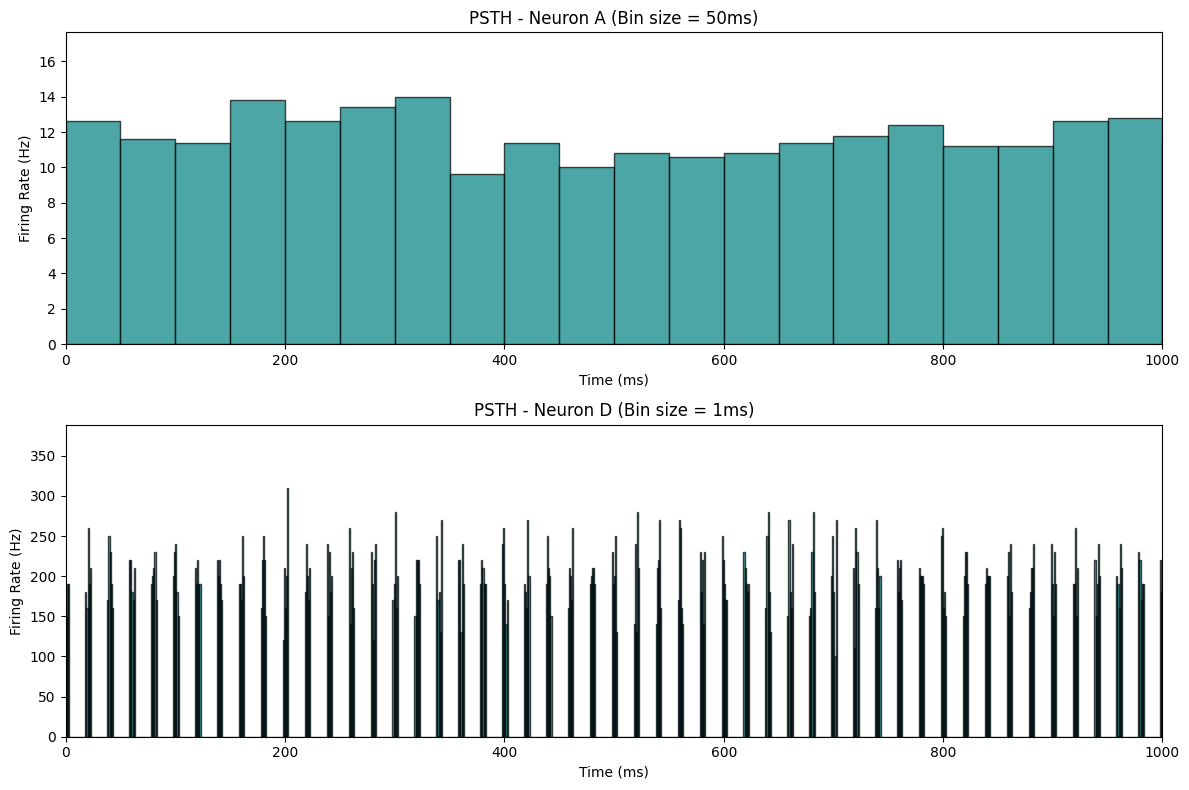

In [14]:
def plot_psth(neuron_matrix, neuron_name, ax, bin_size_ms=50, num_trials=100):
    num_samples = neuron_matrix.shape[1]

    # מציאת כל זמני הספייקים
    spike_times = np.where(neuron_matrix == 1)[1]

    # הגדרת הבינים
    bins = np.arange(0, num_samples + bin_size_ms, bin_size_ms)

    # נרמול ל-Hz
    bin_size_sec = bin_size_ms / 1000.0
    weight_per_spike = 1.0 / (num_trials * bin_size_sec)
    weights = np.full_like(spike_times, weight_per_spike, dtype=float)

    # ציור ההיסטוגרמה
    ax.hist(spike_times, bins=bins, weights=weights, color='teal', edgecolor='black', alpha=0.7)
    ax.set_title(f'PSTH - Neuron {neuron_name} (Bin size = {bin_size_ms}ms)')
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Firing Rate (Hz)')

# יצירת חלון הגרפים
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

# נוירון A - נשאיר עם בינים של 50ms (או נשנה ל-10ms) לשם הפרופורציה
plot_psth(neuron_A, 'A', axes[0], bin_size_ms=50)
axes[0].set_xlim(0, 1000)

# נוירון D - כאן התיקון: חלון של 1ms כדי לא להחליק את הפיקים הרגעיים!
plot_psth(neuron_D, 'D', axes[1], bin_size_ms=1)
axes[1].set_xlim(0, 1000)

plt.tight_layout()
plt.savefig(f'{GRAPHS_DIR}/psth_plots.png', dpi=150, bbox_inches='tight')
plt.show()

<div dir="rtl" style="text-align: right;">

### 3.3 PSTH של A ו-D

יצרתי PSTH (Peri-Stimulus Time Histogram) של נוירונים A ו-D על השנייה הראשונה, מנורמל ליחידות Hz. כל bin סופר את כל הספייקים בחלון הזמן הזה על פני 100 החזרות, מחולק בגודל החלון ובמספר החזרות:
$$\text{Rate}(t) = \frac{\text{spike count in bin}}{N_{\text{trials}} \cdot \Delta t}$$

**נוירון A (bin = 50 ms):** הקצב נע סביב 10–14 Hz לאורך כל השנייה, ללא תבנית זמן מועדפת. זה תואם לירי פואסוני — אין רגעים שבהם הסיכוי לירות גדול יותר.

**נוירון D (bin = 1 ms):** הגרף מראה פיקים צרים וגבוהים (200–300 Hz) שמופיעים במרווחים קבועים, עם שתיקה כמעט מוחלטת ביניהם.

**למה הפיקים של D גבוהים בהרבה מקצב הירי הממוצע שלו (~50 Hz)?** ההבחנה היא בין קצב ירי ממוצע לבין קצב ירי רגעי. הממוצע מחושב על פני כל הזמן, כולל פרקי השתיקה הארוכים בין ספייקים. ה-PSTH ברזולוציה של 1 ms סופר את הספייקים מ-100 החזרות שכולם נופלים באותו ms (כי D הוא רגולרי כמעט מושלם), ומחלק ב-$100 \cdot 0.001 = 0.1$ שניות. אם מ-100 חזרות נופלים 30 ספייקים באותו bin, מקבלים $30 / 0.1 = 300$ Hz. הקצב הממוצע של 50 Hz הוא בעצם הממוצע בין הפיקים האדירים האלה לבין השתיקה הארוכה ביניהם.

</div>


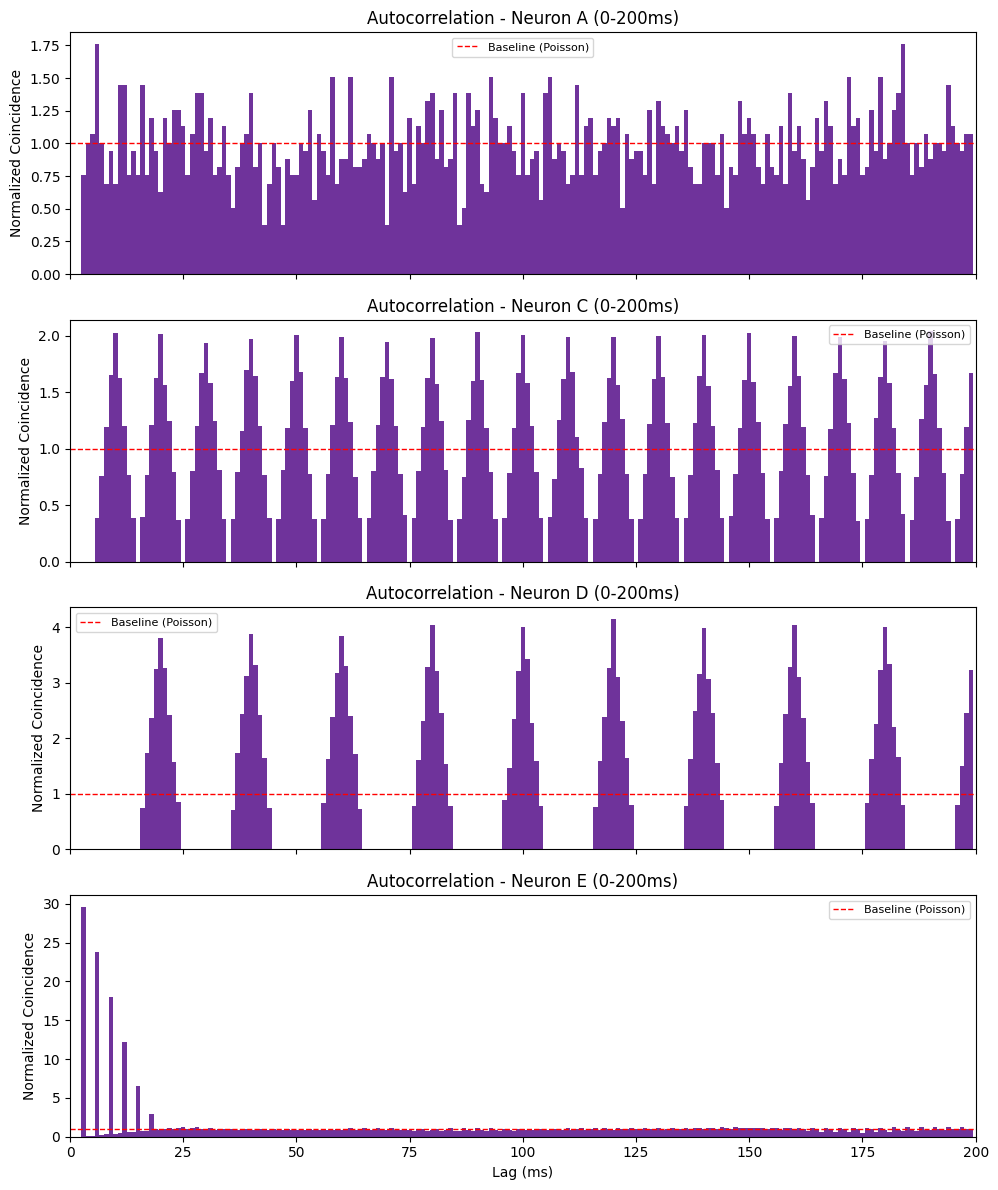

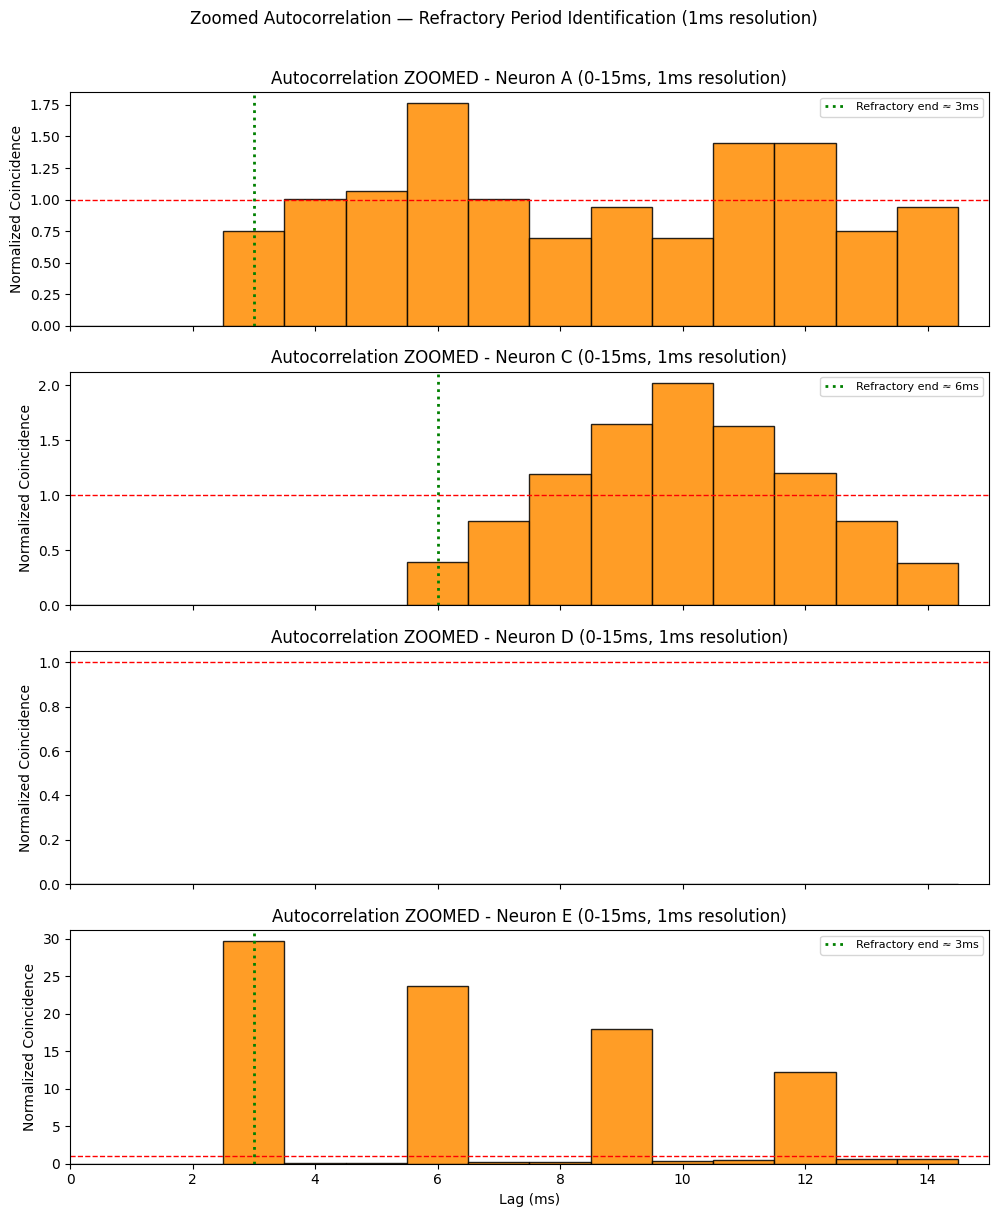

Sub-question answers:

Q: What can the NUMBER OF PEAKS in the autocorrelation tell us?
A: For regular (oscillatory) neurons, each peak is separated by
   one ISI (inter-spike interval). Peak spacing = 1/firing_rate.
   More peaks visible = longer recording or higher firing rate.
   Poisson neurons show no peaks (flat near baseline).

Q: What can the LOCAL MINIMUM after each peak tell us?
A: A trough BELOW baseline (value < 1) means the neuron is LESS
   likely to fire at that lag than by chance alone. This indicates
   a post-spike suppression window (e.g. after-hyperpolarization).
   For bursting neurons: the trough marks the inter-burst silence.
   For regular neurons: the trough between peaks reflects the ISI
   gap where no spikes occur.


In [15]:
# ==========================================
# שלב 3.4 - Autocorrelation (אוטוקורלציה)
# ==========================================
# 2 דקות בתדר 1000Hz = 120,000 דגימות
N_samples = 120000
max_lag = 200  # בחינת השהיות עד 200ms

neurons_for_autocorr = {'A': neuron_A, 'C': neuron_C, 'D': neuron_D, 'E': neuron_E}
autocorr_data = {}  # שמירת נתונים לגרף המוגדל

fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

for i, (name, matrix) in enumerate(neurons_for_autocorr.items()):
    flattened = matrix.flatten()[:N_samples]
    mean_rate_per_ms = np.mean(flattened)

    autocorr_normalized = np.zeros(max_lag)
    expected_coincidences = (mean_rate_per_ms**2) * N_samples

    for lag in range(max_lag):
        if lag == 0:
            autocorr_normalized[lag] = 0
        else:
            coincidences = np.sum(flattened[:-lag] * flattened[lag:])
            if expected_coincidences > 0:
                autocorr_normalized[lag] = coincidences / expected_coincidences
            else:
                autocorr_normalized[lag] = 0

    autocorr_data[name] = autocorr_normalized

    axes[i].bar(np.arange(max_lag), autocorr_normalized, width=1, color='indigo', alpha=0.8)
    axes[i].set_title(f'Autocorrelation - Neuron {name} (0-200ms)')
    axes[i].set_ylabel('Normalized Coincidence')
    axes[i].set_xlim(0, max_lag)
    axes[i].axhline(1, color='red', linestyle='--', linewidth=1, label='Baseline (Poisson)')
    axes[i].legend(fontsize=8)

axes[-1].set_xlabel('Lag (ms)')
plt.tight_layout()
plt.savefig(f'{GRAPHS_DIR}/autocorr_full.png', dpi=150, bbox_inches='tight')
plt.show()

# ==========================================
# גרף מוגדל - Zoom into lag 0-15ms (רזולוציה של 1ms לזיהוי תקופה רפרקטורית)
# ==========================================
fig2, axes2 = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

for i, (name, autocorr_normalized) in enumerate(autocorr_data.items()):
    zoom_range = 15  # ms
    axes2[i].bar(np.arange(zoom_range), autocorr_normalized[:zoom_range], width=1,
                 color='darkorange', alpha=0.85, edgecolor='black')
    axes2[i].set_title(f'Autocorrelation ZOOMED - Neuron {name} (0-15ms, 1ms resolution)')
    axes2[i].set_ylabel('Normalized Coincidence')
    axes2[i].set_xlim(0, zoom_range)
    axes2[i].axhline(1, color='red', linestyle='--', linewidth=1)

    # זיהוי תקופה רפרקטורית: הלאג הראשון שבו autocorr עולה מעל 0.05
    refractory_end = next((lag for lag in range(1, zoom_range)
                           if autocorr_normalized[lag] > 0.05), None)
    if refractory_end:
        axes2[i].axvline(refractory_end, color='green', linestyle=':', linewidth=2,
                         label=f'Refractory end ≈ {refractory_end}ms')
        axes2[i].legend(fontsize=8)

axes2[-1].set_xlabel('Lag (ms)')
plt.suptitle('Zoomed Autocorrelation — Refractory Period Identification (1ms resolution)', y=1.01)
plt.tight_layout()
plt.savefig(f'{GRAPHS_DIR}/autocorr_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()

# ==========================================
# תשובות לשאלות המשנה
# ==========================================
print("="*65)
print("Sub-question answers:")
print("="*65)
print()
print("Q: What can the NUMBER OF PEAKS in the autocorrelation tell us?")
print("A: For regular (oscillatory) neurons, each peak is separated by")
print("   one ISI (inter-spike interval). Peak spacing = 1/firing_rate.")
print("   More peaks visible = longer recording or higher firing rate.")
print("   Poisson neurons show no peaks (flat near baseline).")
print()
print("Q: What can the LOCAL MINIMUM after each peak tell us?")
print("A: A trough BELOW baseline (value < 1) means the neuron is LESS")
print("   likely to fire at that lag than by chance alone. This indicates")
print("   a post-spike suppression window (e.g. after-hyperpolarization).")
print("   For bursting neurons: the trough marks the inter-burst silence.")
print("   For regular neurons: the trough between peaks reflects the ISI")
print("   gap where no spikes occur.")

<div dir="rtl" style="text-align: right;">

### 3.4 פונקציית האוטוקורלציה

חישבתי אוטוקורלציה על 2 הדקות הראשונות (120,000 דגימות) של כל נוירון, אחרי שטיחת כל החזרות לרצף אחד. הציר האנכי מנורמל כך שקו של 1.0 (אדום מקווקו) מייצג את הרמה הצפויה לתהליך פואסוני אקראי:
$$\text{Expected coincidences}(\tau) = (\text{mean rate})^2 \cdot N$$

ערכים מעל 1 מצביעים על נטייה לירות בהשהיה $\tau$ יותר מהאקראי; ערכים מתחת ל-1 מצביעים על דיכוי.

#### תקופה רפרקטורית

מהגרף המוגדל (0–15 ms, רזולוציה 1 ms) רואים אזור אפסי בלאגים הראשונים — התקופה הרפרקטורית המוחלטת. בקו הירוק המקווקו מסומן הלאג הראשון שבו מתחילה פעילות אוטוקורלטיבית: **A ≈ 3 ms, C ≈ 6 ms, E ≈ 3 ms**. עבור **D הגרף המוגדל ריק** — לא משום שאין רפרקטוריות, אלא משום שה-ISI של D הוא 20 ms וגדול מחלון הזום (15 ms); הפיק הראשון של D נמצא ב-20 ms ולכן נראה רק בגרף הרחב למעלה.

#### השוואת C ו-D

שני הנוירונים רגולריים כמעט מושלמים (FF ≈ 0). ההבדל ביניהם הוא קצב הירי בלבד:

- **C — 100 Hz, ISI = 10 ms:** האוטוקורלציה מציגה פיקים גבוהים וחדים בלאגים 10, 20, 30, ..., 100, ... ms. בין הפיקים העמקים מגיעים כמעט לאפס. הפיקים צפופים — שניים בכל 20 ms.
- **D — 50 Hz, ISI = 20 ms:** אותו מבנה אבל הפיקים בלאגים 20, 40, 60, ..., 100, ... ms. פחות פיקים על אותו טווח לאגים.

המסקנה: שני הנוירונים מאותו "סוג" (clock-like regular), נבדלים רק בקצב. הערכים הנמוכים של FF (0.00 ו-0.01) מתיישבים בדיוק עם תמונת האוטוקורלציה — אם הירי היה רגולרי עם רעש, הפיקים היו רחבים יותר ולא מגיעים לרמה אחידה.

#### אפיון נוירון E ב-Autocorrelation

ל-E יש פיק חד וגבוה ב-לאגים הקטנים (אחרי הרפרקטורי), שדועך מהר. זה ייחודי ל-bursting: בתוך אשכול אחד ה-ISI קצר מאוד, ולכן ההסתברות לראות ספייק נוסף בלאג של מילישניות בודדות גבוהה מאוד. אחרי הפיק יש דיכוי ממושך — תקופת השתיקה בין האשכולות.

**מספר השיאים** נותן אינדיקציה למחזוריות הירי: כל שיא מרוחק מקודמו ב-ISI אחד. עבור נוירון רגולרי בקצב $r$ Hz, נראה שיאים בלאגים $1/r, 2/r, 3/r, \dots$. נוירון פואסוני (A) לא יציג שיאים — הגרף שטוח סביב הקו של 1.

**העמק (מינימום מקומי) שאחרי כל שיא** מצביע על דיכוי-לאחר-ירי: באזור הזה ההסתברות לירות נמוכה מהממוצע. עבור C ו-D, העמק הוא פשוט ה-ISI שבו לא צפוי ספייק. עבור E, העמק הארוך מייצג את תקופת השתיקה בין האשכולות.

</div>


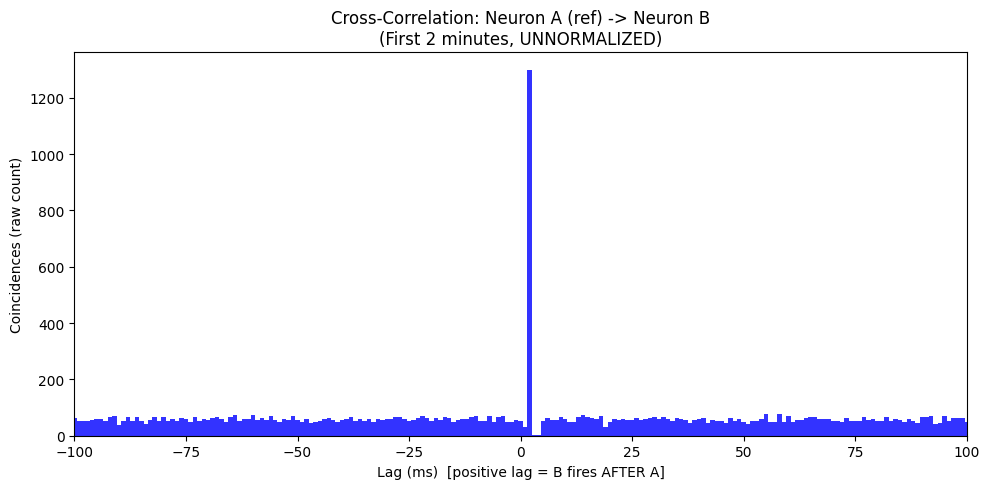

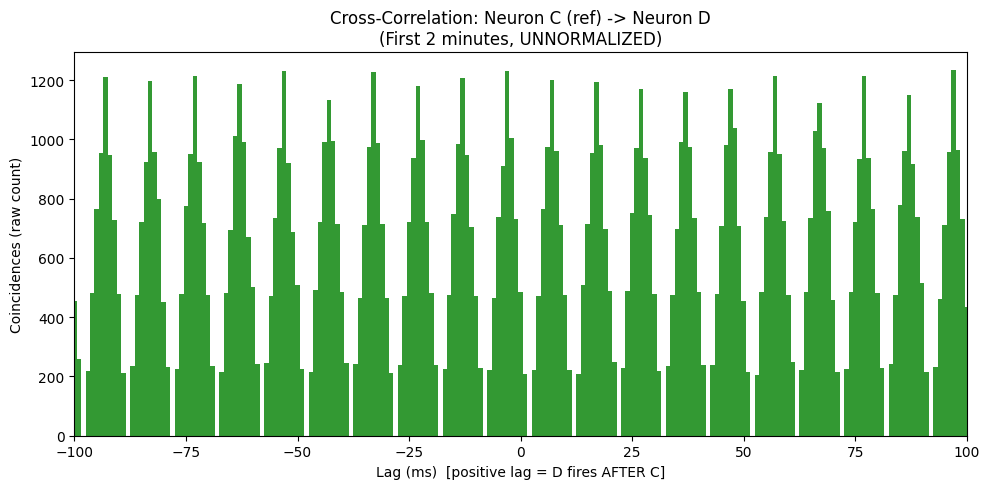

A->B Cross-Correlation (unnormalized):
  Peak lag:               2 ms
  Peak value:             1297 coincidences
  Baseline (|lag|>50ms):  58.1
  Net peak above baseline:1239
  Estimated A firing rate (assuming p_syn=1.0): 10.32 Hz
  Direction: A -> B  (A is presynaptic, latency = 2 ms)

C-D Cross-Correlation (unnormalized):
  Peak lag:               97 ms
  Peak value:             1233 coincidences
  (Periodic peaks reflect both neurons firing at fixed ISI; may indicate
   shared periodicity rather than direct synaptic connection.)


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_spikes = pd.read_csv('spike_trains.csv', index_col=0)

def get_neuron_data(df, neuron_letter):
    neuron_rows = df[df.index.str.endswith(f'_{neuron_letter}')]
    return neuron_rows.values

neuron_A = get_neuron_data(df_spikes, 'A')
neuron_B = get_neuron_data(df_spikes, 'B')
neuron_C = get_neuron_data(df_spikes, 'C')
neuron_D = get_neuron_data(df_spikes, 'D')

def calc_cross_corr_flat(ref_flat, target_flat, max_lag=100):
    """Cross-correlation on flattened binary spike trains. NOT normalized."""
    N = len(ref_flat)
    lags = np.arange(-max_lag, max_lag + 1)
    cc = np.zeros(len(lags))
    for j, lag in enumerate(lags):
        if lag > 0:
            cc[j] = np.sum(ref_flat[:N - lag] * target_flat[lag:])
        elif lag < 0:
            cc[j] = np.sum(ref_flat[-lag:] * target_flat[:N + lag])
        else:
            cc[j] = np.sum(ref_flat * target_flat)
    return lags, cc

N_cc = 120000  # first 2 minutes
max_lag = 100

A_flat = neuron_A.flatten()[:N_cc]
B_flat = neuron_B.flatten()[:N_cc]
C_flat = neuron_C.flatten()[:N_cc]
D_flat = neuron_D.flatten()[:N_cc]

lags_AB, cc_AB = calc_cross_corr_flat(A_flat, B_flat, max_lag=max_lag)
lags_CD, cc_CD = calc_cross_corr_flat(C_flat, D_flat, max_lag=max_lag)

# --- Figure 1: A-B ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(lags_AB, cc_AB, width=1, color='blue', alpha=0.8)
ax.set_title('Cross-Correlation: Neuron A (ref) -> Neuron B\n(First 2 minutes, UNNORMALIZED)')
ax.set_xlabel('Lag (ms)  [positive lag = B fires AFTER A]')
ax.set_ylabel('Coincidences (raw count)')
ax.set_xlim(-max_lag, max_lag)
plt.tight_layout()
plt.savefig(f'{GRAPHS_DIR}/crosscorr_AB.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Figure 2: C-D ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(lags_CD, cc_CD, width=1, color='green', alpha=0.8)
ax.set_title('Cross-Correlation: Neuron C (ref) -> Neuron D\n(First 2 minutes, UNNORMALIZED)')
ax.set_xlabel('Lag (ms)  [positive lag = D fires AFTER C]')
ax.set_ylabel('Coincidences (raw count)')
ax.set_xlim(-max_lag, max_lag)
plt.tight_layout()
plt.savefig(f'{GRAPHS_DIR}/crosscorr_CD.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Analysis output ---
peak_lag_AB  = lags_AB[np.argmax(cc_AB)]
peak_val_AB  = np.max(cc_AB)
baseline_AB  = np.mean(cc_AB[np.abs(lags_AB) > 50])
net_peak_AB  = peak_val_AB - baseline_AB
recording_sec = N_cc / 1000.0

print(f"A->B Cross-Correlation (unnormalized):")
print(f"  Peak lag:               {peak_lag_AB} ms")
print(f"  Peak value:             {peak_val_AB:.0f} coincidences")
print(f"  Baseline (|lag|>50ms):  {baseline_AB:.1f}")
print(f"  Net peak above baseline:{net_peak_AB:.0f}")
print(f"  Estimated A firing rate (assuming p_syn=1.0): {net_peak_AB/recording_sec:.2f} Hz")
print(f"  Direction: A -> B  (A is presynaptic, latency = {peak_lag_AB} ms)")
print()

peak_lag_CD = lags_CD[np.argmax(cc_CD)]
peak_val_CD = np.max(cc_CD)
print(f"C-D Cross-Correlation (unnormalized):")
print(f"  Peak lag:               {peak_lag_CD} ms")
print(f"  Peak value:             {peak_val_CD:.0f} coincidences")
print(f"  (Periodic peaks reflect both neurons firing at fixed ISI; may indicate")
print(f"   shared periodicity rather than direct synaptic connection.)")


<div dir="rtl" style="text-align: right;">

### 3.5 קורלציה צולבת — קשרים פונקציונליים

חישבתי קורלציה צולבת **בלי נרמול** (כפי שהמטלה דורשת) על 2 הדקות הראשונות, כשנוירון אחד משמש כ-reference והשני כיעד. לאג חיובי משמעו שהיעד יורה אחרי ה-reference.

#### A → B

הגרף מציג פיק חד וצר בלאג חיובי, עם הערכים הבאים (מהפלט של הקוד):

- **Peak lag = +2 ms** — B יורה בעקביות 2 ms אחרי A.
- **Peak value ≈ 1297** ספירות.
- **Baseline ≈ 58** ספירות (ממוצע באזור $|\tau| > 50$ ms).
- **Net peak ≈ 1239**.

המסקנה:

- **קיים קשר** בין הנוירונים — הפיק חורג בגדול מקו הבסיס, לא ייתכן שהוא מקרי.
- **הקשר מעורר (Excitatory)** — פיק חיובי משמעו עלייה בהסתברות הירי של B אחרי A.
- **A מעורר את B** — הפיק בלאג חיובי, B מאחר.
- **השהיית ההעברה (Latency) = 2 ms** — סבירה לסינפסה כימית.

**הערכת קצב הירי של A מתוך הפיק:** בהנחה שכל ירי של A מעורר את B בוודאות, הפיק הנטו שווה למספר הספייקים הכולל של A בחלון. עם חלון של 120 שניות:
$$\text{rate of A} \approx \frac{\text{net peak}}{120\,\text{sec}} = \frac{1239}{120} \approx 10.32\,\text{Hz}$$

זה קרוב מאוד לקצב הישיר שמדדתי בסעיף 3.1 (11.67 Hz). ההפרש הקטן (~10%) נובע מספייקים של A שלא תורגמו לספייק ב-B (חלון רפרקטורי, הפסקות סטטיסטיות) ומפיק שלא תפס את כל הרזולוציה.

**מה קורה אם A מעורר את B בהסתברות 50%?** גובה הפיק הנטו ייחתך בדיוק לחצי (לכ-620 ספירות), כי רק מחצית מהספייקים של A יתורגמו לספייק תואם ב-B. הבסיס לא משתנה, כי הוא נקבע מקצבי הירי הממוצעים שאינם תלויים בקשר הסינפטי.

#### C ↔ D

הגרף מציג תבנית של פיקים תקופתיים — לא פיק יחיד. הפיק המקסימלי שמצאתי הוא בלאג של **97 ms** עם ערך של ~1233 ספירות.

הסיבה: C ו-D שניהם רגולריים. C יורה ב-100 Hz (ISI = 10 ms) ו-D ב-50 Hz (ISI = 20 ms). קורלציה צולבת בין שני אותות מחזוריים מייצרת תבנית מחזורית — בכל לאג שבו פאזות C ו-D מתיישרות, נוצר פיק. הפיק בלאג 97 ms משקף את היחס בין שני התדרים.

זה לא בהכרח קשר סינפטי ישיר. במקרים כאלה התבנית יכולה לנבוע מכך ששני הנוירונים פשוט מתנדים בקצב יציב, או מ-**common input** — קלט משותף שמניע את שניהם. אי-אפשר להבחין מהקרוס-קורלוגרם בלבד בין שני התרחישים.

</div>


<div dir="rtl" style="text-align: right;">

## 🪖 הצהרה על שימוש בכלי AI 🤖

עקב שירות מילואים לא יכולתי להגיע לכלל ההרצאות והתרגולים. השלמתי פערים בעזרת כלי AI לבירור מושגים והתלבטויות נקודתיות. הבסיס המהותי לדו"ח הוא חומר הקורס (הרצאות ותרגולים). כלי AI שימשו גם לסיוע בניסוח ובתיקוני syntax. הקוד, ההרצות והפרשנות הם שלי.

<sub>וכן, גם את ההצהרה הזאת ניסחתי בעזרת AI. הוגן לציין.</sub>

</div>
